# Compositional Contextual Expert Bandits [CCEB]

## Part 1: Defining The Inference System

In [1]:
import torch
# Disable gradient calculations globally
torch.set_grad_enabled(False)
# Set so that each particle will only use one thread
torch.set_num_threads(1)
torch.set_num_interop_threads(1)
# set torch print options, including line width
torch.set_printoptions(precision=4, sci_mode=False, linewidth=250)

import numpy as np

import torch.distributions as D
import matplotlib.pyplot as plt
from copy import deepcopy
from concurrent.futures import ProcessPoolExecutor

In [2]:
from ensemble import Ensemble
from particle import print_particle_params, Particle
from utils_categorical import cat_sample

/scratch/venvs/generic312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Part 1: Defining the experiment

### Define the various contexts that can be encountered

In [3]:
NOISE = 0.02

dist_c_0_s_0 = D.MultivariateNormal(loc=torch.tensor([1.0, 0.0, 0.0]), covariance_matrix=torch.eye(3)*NOISE)
dist_c_0_s_1 = D.MultivariateNormal(loc=torch.tensor([-1.0, 0.0, 0.0]), covariance_matrix=torch.eye(3)*NOISE)

dist_c_1_s_0 = D.MultivariateNormal(loc=torch.tensor([0.0, 1.0, 0.0]), covariance_matrix=torch.eye(3)*NOISE)
dist_c_1_s_1 = D.MultivariateNormal(loc=torch.tensor([0.0, -1.0, 0.0]), covariance_matrix=torch.eye(3)*NOISE)

dist_c_2_s_0 = D.MultivariateNormal(loc=torch.tensor([0.0, 0.0, 1.0]), covariance_matrix=torch.eye(3)*NOISE)
dist_c_2_s_1 = D.MultivariateNormal(loc=torch.tensor([0.0, 0.0, -1.0]), covariance_matrix=torch.eye(3)*NOISE)

def generate_observation(true_c_o, true_s):
    """
    Three possible observation contexts
    """
    # select randomly between the two versions of each context, to make the marginals identical across contexts
    if true_c_o == 0:
        if true_s == 0:
            return dist_c_0_s_0.sample()
        else:
            return dist_c_0_s_1.sample()
    
    elif true_c_o == 1:
        if true_s == 0:
            return dist_c_1_s_0.sample()
        else:
            return dist_c_1_s_1.sample()
    
    elif true_c_o == 2:
        if true_s == 0:
            return dist_c_2_s_0.sample()
        else:
            return dist_c_2_s_1.sample()
    else:
        raise ValueError("true_c must be 0, 1, or 2")


def generate_reward(true_s, a_t, true_c_r):
    """
    Two possible reward contexts
    """
    
    if true_c_r == 0:
        if true_s == 0:
            return 1.0 if a_t == 0 else 0.0
        else:
            return 1.0 if a_t == 1 else 0.0
    elif true_c_r == 1:
        if true_s == 0:
            return 1.0 if a_t == 2 else 0.0
        else:
            return 1.0 if a_t == 3 else 0.0
    else:
        raise ValueError("true_s must be 0 or 1")

#### Definte a series of trials in the same context

In [4]:


def batched_trials(ensemble: Ensemble, true_c_o_t, true_c_r_t, n_steps=50, histories : dict[str, list]=None):
    """
    Run a batch of trials with the given context combination.
    """

    print(f"\n << Running {n_steps} trials with true_c_o_t={true_c_o_t}, true_c_r_t={true_c_r_t} >> \n")

    for i in range(n_steps):
        print(f"Step {i+1}:")

        # Sample state and observation
        true_s_t = cat_sample(torch.tensor([0.5, 0.5]))
        o_t = generate_observation(true_c_o_t, true_s_t)
        
        print(f"\tTrue state: {true_s_t}, Observation: {np.array2string(o_t.numpy(), formatter={'float_kind':lambda x: f'{x: .1f}'})}")
        
        # Process observation
        ensemble.before_action(o_t)    
        
        # Select action
        a_t, actions = ensemble.select_action()
        
        # Generate reward
        r_t = generate_reward(true_s_t, a_t, true_c_r_t)

        # count proportion of particles selecting each action
        action_counts = np.bincount(actions.numpy(), minlength=4)
        action_proportions = action_counts / ensemble.N
        action_proportions = np.array2string(action_proportions, formatter={'float_kind':lambda x: f"{x: .2f}"})
        print(f"\tAction proportions: {action_proportions}, Selected action: {a_t}, Reward: {r_t}")

        # Update model
        ensemble.after_action(a_t, r_t, o_t)
        
        # Record keeping
        histories['context_o_hist'].append(ensemble.vec_c_o_t.clone().detach().numpy())
        histories['jumps_hist'].append(ensemble.vec_j_t.clone().detach().numpy())
        histories['actions_hist'].append(actions.clone().detach().numpy())
        if true_c_r_t == 0:
            histories['true_rewarding_actions'].append(0 if true_s_t == 0 else 1)
        elif true_c_r_t == 1:
            histories['true_rewarding_actions'].append(2 if true_s_t == 0 else 3)
        histories['context_r_hist'].append(ensemble.vec_c_r_t.clone().detach().numpy())
        histories['inferred_s_hist'].append(ensemble.vec_s_t.clone().detach().numpy())
        histories['true_s_hist'].append(true_s_t)

## Part 2: Run Simulation

In [5]:
HYP_GAMMA = 0.05
HYP_ALPHA_O = 0.1
HYP_ALPHA_R = 0.1
HYP_NIW = {
    'mu0': torch.tensor([0.0, 0.0, 0.0]),
    'kappa0': 0.1,
    'nu0': 4.0,
    'Lambda0': torch.eye(3) * 1.0 
}
HYP_BB = {
    'alpha0': torch.tensor([0.5, 0.5, 0.5, 0.5]),
    'beta0': torch.tensor([0.5, 0.5, 0.5, 0.5])
}

#### Simulation


 << Running 50 trials with true_c_o_t=0, true_c_r_t=0 >> 

Step 1:
	True state: 0, Observation: [ 1.1 -0.1  0.1]
	Action proportions: [ 0.32  0.27  0.22  0.20], Selected action: 1, Reward: 0.0
Step 2:
	True state: 1, Observation: [-1.1  0.2 -0.0]
	Action proportions: [ 0.32  0.15  0.28  0.25], Selected action: 3, Reward: 0.0
Step 3:
	True state: 1, Observation: [-1.0 -0.1  0.0]
	Action proportions: [ 0.34  0.18  0.36  0.12], Selected action: 0, Reward: 0.0
Step 4:
	True state: 1, Observation: [-1.1 -0.3  0.1]
	Action proportions: [ 0.14  0.28  0.43  0.14], Selected action: 1, Reward: 1.0
Step 5:
	True state: 0, Observation: [ 0.6 -0.0 -0.0]
	Action proportions: [ 0.24  0.16  0.37  0.23], Selected action: 1, Reward: 0.0
Step 6:
	True state: 0, Observation: [ 1.0  0.3 -0.0]
	Action proportions: [ 0.30  0.07  0.32  0.30], Selected action: 2, Reward: 0.0
Step 7:
	True state: 1, Observation: [-0.8  0.1 -0.1]
	Action proportions: [ 0.05  0.60  0.29  0.06], Selected action: 1, Reward: 1.0
St

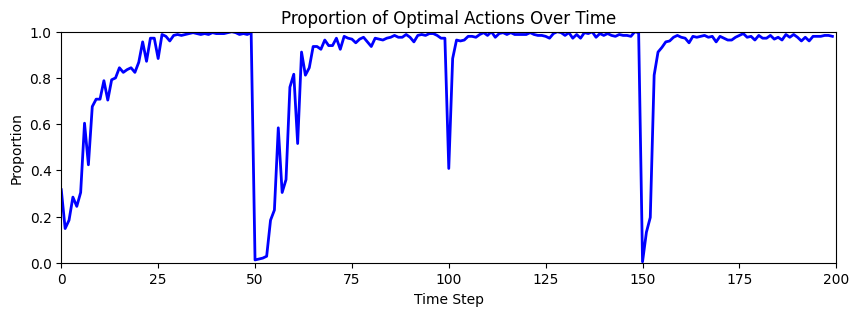


 << Running 50 trials with true_c_o_t=0, true_c_r_t=0 >> 

Step 1:
	True state: 1, Observation: [-0.9 -0.0  0.2]
	Action proportions: [ 0.25  0.26  0.27  0.22], Selected action: 0, Reward: 0.0
Step 2:
	True state: 0, Observation: [ 0.7  0.1  0.2]
	Action proportions: [ 0.09  0.32  0.33  0.26], Selected action: 2, Reward: 0.0
Step 3:
	True state: 1, Observation: [-0.8  0.1  0.0]
	Action proportions: [ 0.11  0.36  0.15  0.39], Selected action: 3, Reward: 0.0
Step 4:
	True state: 1, Observation: [-1.1 -0.1  0.0]
	Action proportions: [ 0.18  0.46  0.22  0.14], Selected action: 0, Reward: 0.0
Step 5:
	True state: 1, Observation: [-1.0 -0.0 -0.2]
	Action proportions: [ 0.08  0.50  0.28  0.14], Selected action: 1, Reward: 1.0
Step 6:
	True state: 0, Observation: [ 1.2  0.0 -0.1]
	Action proportions: [ 0.23  0.47  0.10  0.19], Selected action: 2, Reward: 0.0
Step 7:
	True state: 1, Observation: [-1.0  0.3 -0.0]
	Action proportions: [ 0.04  0.64  0.25  0.07], Selected action: 2, Reward: 0.0
St

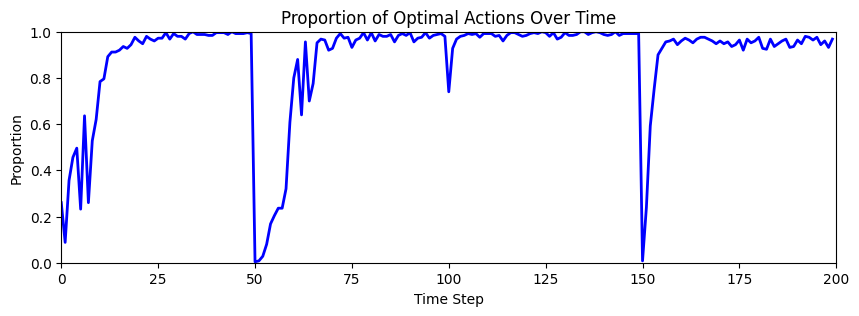


 << Running 50 trials with true_c_o_t=0, true_c_r_t=0 >> 

Step 1:
	True state: 1, Observation: [-1.1  0.0  0.2]
	Action proportions: [ 0.26  0.22  0.25  0.27], Selected action: 1, Reward: 1.0
Step 2:
	True state: 1, Observation: [-1.1 -0.0 -0.3]
	Action proportions: [ 0.17  0.50  0.17  0.16], Selected action: 1, Reward: 1.0
Step 3:
	True state: 1, Observation: [-0.9 -0.1 -0.0]
	Action proportions: [ 0.19  0.46  0.17  0.18], Selected action: 0, Reward: 0.0
Step 4:
	True state: 1, Observation: [-1.0 -0.3  0.1]
	Action proportions: [ 0.03  0.62  0.18  0.18], Selected action: 3, Reward: 0.0
Step 5:
	True state: 0, Observation: [ 0.9 -0.0 -0.0]
	Action proportions: [ 0.21  0.38  0.25  0.16], Selected action: 1, Reward: 0.0
Step 6:
	True state: 1, Observation: [-0.9  0.0 -0.1]
	Action proportions: [ 0.07  0.66  0.23  0.04], Selected action: 1, Reward: 1.0
Step 7:
	True state: 0, Observation: [ 1.1  0.0  0.1]
	Action proportions: [ 0.28  0.10  0.34  0.28], Selected action: 0, Reward: 1.0
St

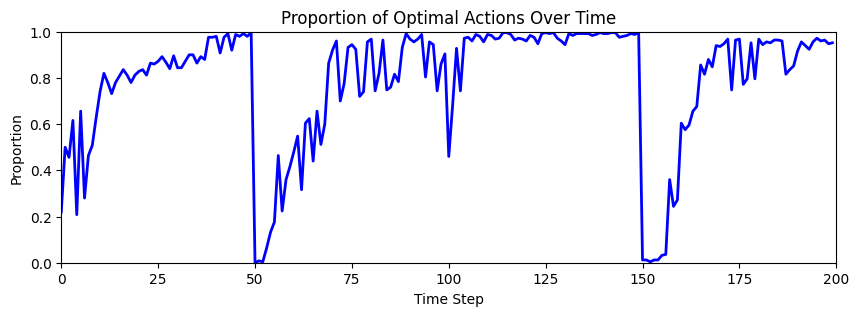


 << Running 50 trials with true_c_o_t=0, true_c_r_t=0 >> 

Step 1:
	True state: 1, Observation: [-1.0  0.1 -0.1]
	Action proportions: [ 0.23  0.24  0.28  0.26], Selected action: 2, Reward: 0.0
Step 2:
	True state: 1, Observation: [-1.0 -0.2 -0.1]
	Action proportions: [ 0.29  0.30  0.10  0.31], Selected action: 1, Reward: 1.0
Step 3:
	True state: 1, Observation: [-1.1 -0.2  0.1]
	Action proportions: [ 0.19  0.51  0.03  0.27], Selected action: 1, Reward: 1.0
Step 4:
	True state: 0, Observation: [ 0.8 -0.2  0.0]
	Action proportions: [ 0.24  0.39  0.13  0.24], Selected action: 2, Reward: 0.0
Step 5:
	True state: 1, Observation: [-0.8 -0.2 -0.1]
	Action proportions: [ 0.17  0.59  0.03  0.21], Selected action: 1, Reward: 1.0
Step 6:
	True state: 1, Observation: [-0.8 -0.0  0.0]
	Action proportions: [ 0.15  0.63  0.02  0.19], Selected action: 1, Reward: 1.0
Step 7:
	True state: 1, Observation: [-1.2  0.0 -0.1]
	Action proportions: [ 0.16  0.71  0.01  0.11], Selected action: 0, Reward: 0.0
St

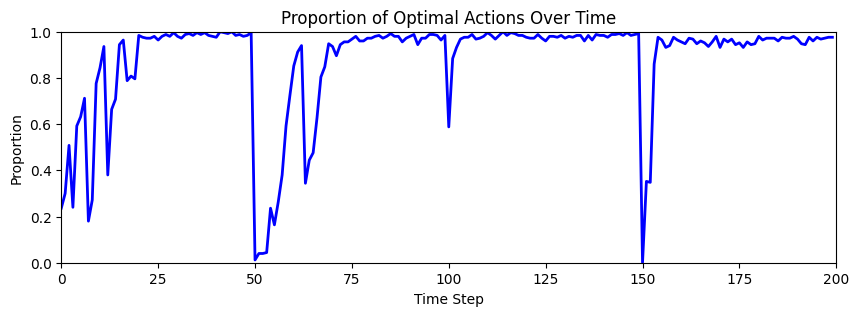


 << Running 50 trials with true_c_o_t=0, true_c_r_t=0 >> 

Step 1:
	True state: 1, Observation: [-1.1 -0.0 -0.2]
	Action proportions: [ 0.24  0.25  0.25  0.26], Selected action: 3, Reward: 0.0
Step 2:
	True state: 0, Observation: [ 1.1 -0.1  0.1]
	Action proportions: [ 0.26  0.32  0.27  0.15], Selected action: 1, Reward: 0.0
Step 3:
	True state: 0, Observation: [ 1.1 -0.2  0.1]
	Action proportions: [ 0.36  0.10  0.35  0.19], Selected action: 0, Reward: 1.0
Step 4:
	True state: 1, Observation: [-1.0 -0.1  0.1]
	Action proportions: [ 0.45  0.21  0.27  0.07], Selected action: 1, Reward: 1.0
Step 5:
	True state: 1, Observation: [-1.1 -0.1 -0.0]
	Action proportions: [ 0.28  0.44  0.24  0.04], Selected action: 0, Reward: 0.0
Step 6:
	True state: 0, Observation: [ 1.2 -0.0  0.1]
	Action proportions: [ 0.50  0.05  0.20  0.26], Selected action: 0, Reward: 1.0
Step 7:
	True state: 0, Observation: [ 0.9  0.2  0.3]
	Action proportions: [ 0.58  0.05  0.17  0.20], Selected action: 2, Reward: 0.0
St

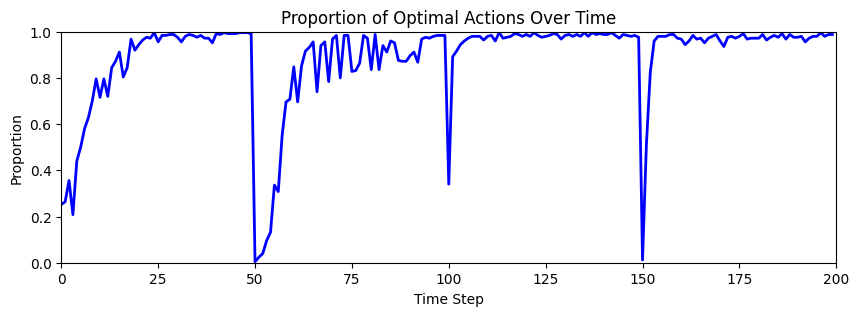


 << Running 50 trials with true_c_o_t=0, true_c_r_t=0 >> 

Step 1:
	True state: 1, Observation: [-1.2 -0.2  0.1]
	Action proportions: [ 0.26  0.22  0.26  0.26], Selected action: 1, Reward: 1.0
Step 2:
	True state: 0, Observation: [ 1.0  0.1 -0.1]
	Action proportions: [ 0.19  0.36  0.25  0.20], Selected action: 0, Reward: 1.0
Step 3:
	True state: 0, Observation: [ 1.0  0.1 -0.2]
	Action proportions: [ 0.40  0.22  0.24  0.14], Selected action: 3, Reward: 0.0
Step 4:
	True state: 1, Observation: [-1.0 -0.0  0.4]
	Action proportions: [ 0.35  0.42  0.15  0.08], Selected action: 1, Reward: 1.0
Step 5:
	True state: 1, Observation: [-0.9 -0.0  0.2]
	Action proportions: [ 0.26  0.51  0.12  0.11], Selected action: 1, Reward: 1.0
Step 6:
	True state: 1, Observation: [-0.9  0.1 -0.0]
	Action proportions: [ 0.21  0.56  0.14  0.08], Selected action: 0, Reward: 0.0
Step 7:
	True state: 1, Observation: [-1.0  0.2 -0.2]
	Action proportions: [ 0.03  0.70  0.18  0.08], Selected action: 1, Reward: 1.0
St

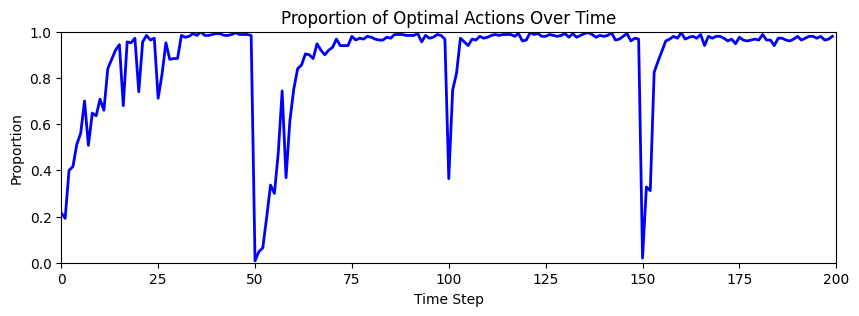


 << Running 50 trials with true_c_o_t=0, true_c_r_t=0 >> 

Step 1:
	True state: 0, Observation: [ 1.0 -0.1  0.1]
	Action proportions: [ 0.28  0.30  0.21  0.21], Selected action: 2, Reward: 0.0
Step 2:
	True state: 0, Observation: [ 1.2  0.2 -0.1]
	Action proportions: [ 0.33  0.31  0.07  0.29], Selected action: 1, Reward: 0.0
Step 3:
	True state: 0, Observation: [ 0.8  0.1 -0.4]
	Action proportions: [ 0.36  0.12  0.11  0.40], Selected action: 3, Reward: 0.0
Step 4:
	True state: 0, Observation: [ 0.9 -0.1  0.1]
	Action proportions: [ 0.52  0.14  0.18  0.16], Selected action: 0, Reward: 1.0
Step 5:
	True state: 1, Observation: [-1.1 -0.2 -0.1]
	Action proportions: [ 0.37  0.24  0.16  0.23], Selected action: 1, Reward: 1.0
Step 6:
	True state: 0, Observation: [ 1.1 -0.3  0.0]
	Action proportions: [ 0.69  0.14  0.07  0.09], Selected action: 0, Reward: 1.0
Step 7:
	True state: 1, Observation: [-1.0 -0.0  0.0]
	Action proportions: [ 0.28  0.38  0.20  0.14], Selected action: 0, Reward: 0.0
St

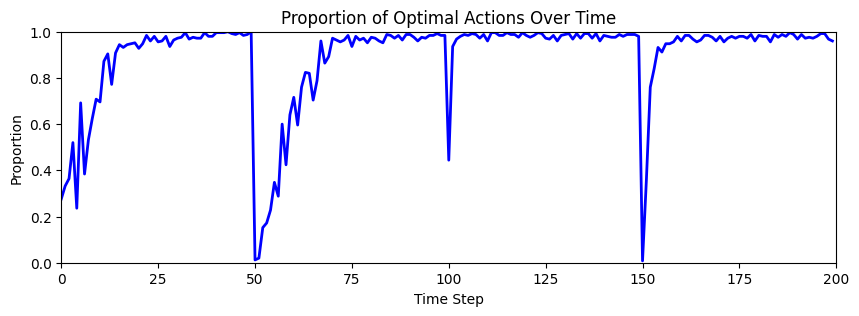


 << Running 50 trials with true_c_o_t=0, true_c_r_t=0 >> 

Step 1:
	True state: 1, Observation: [-0.8  0.0  0.1]
	Action proportions: [ 0.27  0.27  0.25  0.21], Selected action: 0, Reward: 0.0
Step 2:
	True state: 0, Observation: [ 0.9 -0.0 -0.1]
	Action proportions: [ 0.10  0.33  0.30  0.27], Selected action: 1, Reward: 0.0
Step 3:
	True state: 0, Observation: [ 1.1 -0.1 -0.1]
	Action proportions: [ 0.14  0.11  0.37  0.38], Selected action: 2, Reward: 0.0
Step 4:
	True state: 0, Observation: [ 0.9 -0.1  0.1]
	Action proportions: [ 0.24  0.15  0.17  0.44], Selected action: 3, Reward: 0.0
Step 5:
	True state: 1, Observation: [-1.1  0.3  0.1]
	Action proportions: [ 0.16  0.24  0.33  0.28], Selected action: 1, Reward: 1.0
Step 6:
	True state: 1, Observation: [-0.9  0.1  0.1]
	Action proportions: [ 0.04  0.47  0.24  0.25], Selected action: 3, Reward: 0.0
Step 7:
	True state: 1, Observation: [-1.1 -0.1 -0.1]
	Action proportions: [ 0.08  0.58  0.26  0.08], Selected action: 1, Reward: 1.0
St

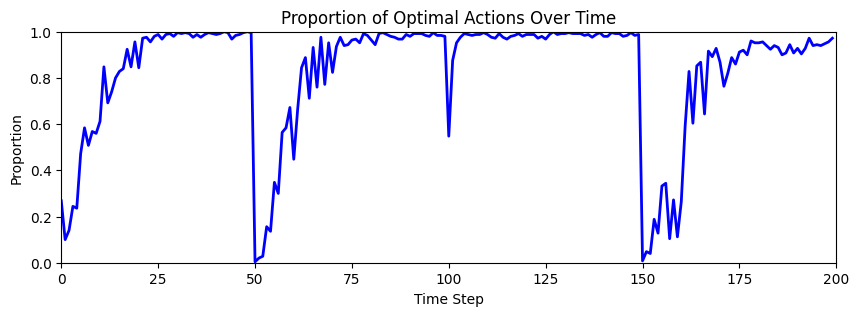


 << Running 50 trials with true_c_o_t=0, true_c_r_t=0 >> 

Step 1:
	True state: 0, Observation: [ 1.2 -0.2 -0.0]
	Action proportions: [ 0.22  0.29  0.25  0.24], Selected action: 3, Reward: 0.0
Step 2:
	True state: 0, Observation: [ 0.9 -0.2 -0.1]
	Action proportions: [ 0.32  0.28  0.34  0.06], Selected action: 2, Reward: 0.0
Step 3:
	True state: 1, Observation: [-1.1 -0.0  0.2]
	Action proportions: [ 0.32  0.30  0.16  0.22], Selected action: 2, Reward: 0.0
Step 4:
	True state: 0, Observation: [ 1.0 -0.1  0.1]
	Action proportions: [ 0.45  0.34  0.07  0.14], Selected action: 1, Reward: 0.0
Step 5:
	True state: 1, Observation: [-1.1  0.0 -0.0]
	Action proportions: [ 0.41  0.24  0.09  0.26], Selected action: 0, Reward: 0.0
Step 6:
	True state: 1, Observation: [-1.0  0.1  0.1]
	Action proportions: [ 0.19  0.36  0.09  0.36], Selected action: 1, Reward: 1.0
Step 7:
	True state: 0, Observation: [ 1.0  0.0 -0.1]
	Action proportions: [ 0.48  0.25  0.13  0.14], Selected action: 1, Reward: 0.0
St

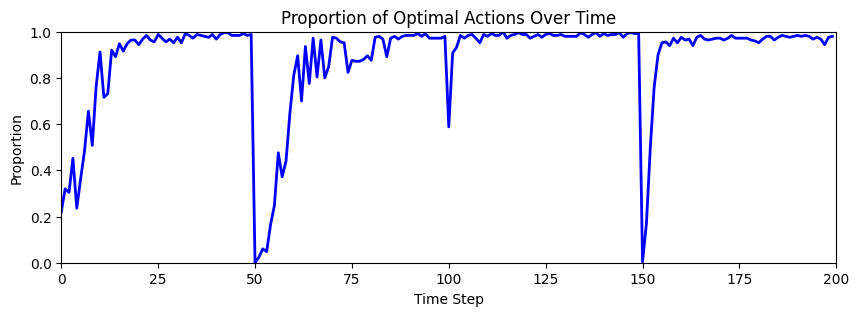


 << Running 50 trials with true_c_o_t=0, true_c_r_t=0 >> 

Step 1:
	True state: 0, Observation: [ 1.2  0.0  0.1]
	Action proportions: [ 0.25  0.24  0.26  0.25], Selected action: 3, Reward: 0.0
Step 2:
	True state: 1, Observation: [-0.7 -0.0  0.0]
	Action proportions: [ 0.28  0.25  0.32  0.14], Selected action: 1, Reward: 1.0
Step 3:
	True state: 1, Observation: [-0.9 -0.2  0.1]
	Action proportions: [ 0.22  0.48  0.19  0.12], Selected action: 1, Reward: 1.0
Step 4:
	True state: 0, Observation: [ 1.2  0.1  0.0]
	Action proportions: [ 0.23  0.44  0.26  0.06], Selected action: 0, Reward: 1.0
Step 5:
	True state: 1, Observation: [-1.0  0.2  0.0]
	Action proportions: [ 0.20  0.49  0.19  0.12], Selected action: 2, Reward: 0.0
Step 6:
	True state: 0, Observation: [ 1.0  0.2 -0.0]
	Action proportions: [ 0.52  0.29  0.17  0.02], Selected action: 1, Reward: 0.0
Step 7:
	True state: 1, Observation: [-1.0 -0.0 -0.1]
	Action proportions: [ 0.20  0.59  0.03  0.18], Selected action: 0, Reward: 0.0
St

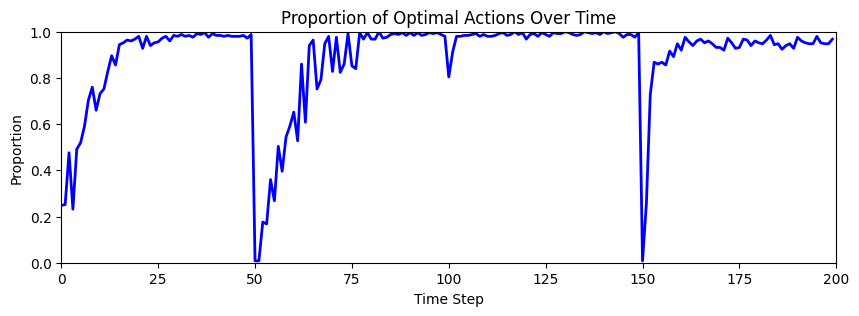

In [6]:
results = []

for i in range(10):

    # Initialize history buffers
    histories = {
    'context_o_hist': [],
    'context_r_hist': [],
    'actions_hist': [],
    'jumps_hist': [],
    'inferred_s_hist': [],
    'true_rewarding_actions': [],   
    'true_s_hist': []
    }


    # Initialize ensemble
    ensemble = Ensemble(N=250, hyp_gamma=HYP_GAMMA, hyp_alpha_o=HYP_ALPHA_O, hyp_alpha_r=HYP_ALPHA_R, hyp_niw=HYP_NIW, hyp_bb=HYP_BB)

    # Run 50 trials in context (c_o=0, c_r=0)
    batched_trials(ensemble, true_c_o_t=0, true_c_r_t=0, n_steps=50, histories=histories)

    # Run 50 trials in context (c_o=1, c_r=1)
    batched_trials(ensemble, true_c_o_t=1, true_c_r_t=1, n_steps=50, histories=histories)

    # Run 50 trials in context (c_o=0, c_r=0)
    batched_trials(ensemble, true_c_o_t=0, true_c_r_t=0, n_steps=50, histories=histories)

    # Run 50 trials in context (c_o=0, c_r=1)
    batched_trials(ensemble, true_c_o_t=0, true_c_r_t=1, n_steps=50, histories=histories)

    results.append(deepcopy(histories))

    print(f"Replicate {i} Proportion of Optimal Actions Over Time:")
    true_rewarding_actions = np.array(results[-1]['true_rewarding_actions'])
    actions_hist_arr = np.array(results[-1]['actions_hist'])
    proportion_optimal = np.zeros(len(actions_hist_arr))
    for idx, element in enumerate(actions_hist_arr):
        proportion_optimal[idx] = np.sum(element == true_rewarding_actions[idx]) / len(element)
    plt.figure(figsize=(10, 3))
    plt.plot(proportion_optimal, label='Proportion Optimal Action', color='blue', linewidth=2)
    plt.title('Proportion of Optimal Actions Over Time')
    plt.xlabel('Time Step')
    plt.ylabel('Proportion')
    plt.ylim(0, 1)
    plt.xlim(0, len(proportion_optimal))
    plt.show()


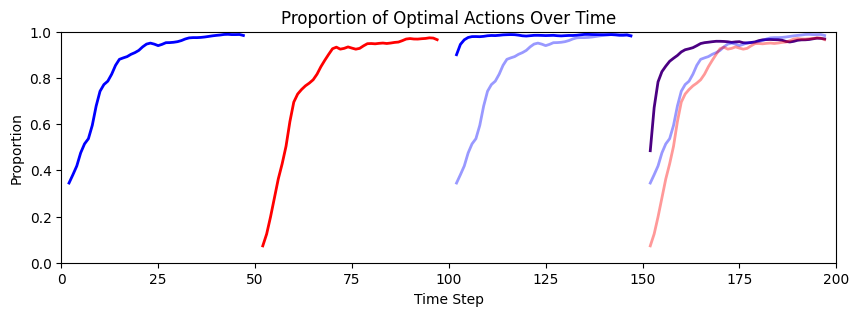

In [25]:
proportion_optimal_mean = np.zeros(200)

chosen = [0, 1, 2, 3, 4, 5, 6, 8, 9]
#0, 1, 3, 4, 5, 8

for j in chosen:

    actions_hist_arr = np.array(results[j]['actions_hist'])
    true_rewarding_actions = results[j]['true_rewarding_actions']

    true_rewarding_actions = np.array(true_rewarding_actions)
    proportion_optimal = np.zeros(len(actions_hist_arr))
    for idx, element in enumerate(actions_hist_arr):
        proportion_optimal[idx] = np.sum(element == true_rewarding_actions[idx]) / len(element)

    proportion_optimal_mean += proportion_optimal

proportion_optimal_mean /= len(chosen)

# gaussian blur with kernel size 5 and sigma 1
from scipy.ndimage import gaussian_filter1d
proportion_optimal_mean = gaussian_filter1d(proportion_optimal_mean, sigma=1.0)

plt.figure(figsize=(10, 3))
#plt.plot(proportion_optimal_mean, label='Proportion Optimal Action', color='blue', linewidth=2)
plt.plot(np.arange(2, 48), proportion_optimal_mean[2:48], color='blue', linewidth=2, alpha=1.0)
plt.plot(np.arange(52, 98), proportion_optimal_mean[52:98], color='red', linewidth=2, alpha=1.0)
plt.plot(np.arange(102, 148), proportion_optimal_mean[102:148], color='blue', linewidth=2, alpha=1.0)
plt.plot(np.arange(152, 198), proportion_optimal_mean[152:198], color='indigo', linewidth=2, alpha=1.0)
plt.plot(np.arange(102, 148), proportion_optimal_mean[2:48], color='blue', linewidth=2, alpha=0.4)
plt.plot(np.arange(152, 198), proportion_optimal_mean[2:48], color='blue', linewidth=2, alpha=0.4)
plt.plot(np.arange(152, 198), proportion_optimal_mean[52:98], color='red', linewidth=2, alpha=0.4)
plt.title('Proportion of Optimal Actions Over Time')
plt.xlabel('Time Step')
plt.ylabel('Proportion')
plt.ylim(0, 1)
plt.xlim(0, len(proportion_optimal))
#plt.savefig("g_proportion_optimal_3.pdf")
plt.show()

## Part 3: Analysis of Results

#### Sanity check of inferred parameters

In [8]:
for particle in ensemble.particles:
    print(f"\n>> Particle {particle}:\n")
    print_particle_params(particle)
    


>> Particle <particle.Particle object at 0x7dfc45f04440>:

> Observation Models:
State 0, Observ Context 0, Observation Model Params: df: 77.0, loc: [ 0.99  0.01  0.02]
State 0, Observ Context 1, Observation Model Params: df: 29.0, loc: [-0.01  1.03 -0.00]
State 1, Observ Context 0, Observation Model Params: df: 77.0, loc: [-1.03  0.02  0.01]
State 1, Observ Context 1, Observation Model Params: df: 25.0, loc: [ 0.05 -0.99  0.03]

Obser. Context CRP Probabilities: [ 0.88  0.11  0.01] Suff Stats: [8. 1.]

> Reward Models:
State 0, Reward Context 0, Reward Model Mean: [ 0.99  0.25  0.25  0.25], Suff Stats: [47.5  0.5  0.5  0.5], [0.5 1.5 1.5 1.5]
State 0, Reward Context 1, Reward Model Mean: [ 0.07  0.17  0.99  0.17], Suff Stats: [ 0.5  0.5 42.5  0.5], [6.5 2.5 0.5 2.5]
State 1, Reward Context 0, Reward Model Mean: [ 0.25  0.99  0.17  0.25], Suff Stats: [ 0.5 46.5  0.5  0.5], [1.5 0.5 2.5 1.5]
State 1, Reward Context 1, Reward Model Mean: [ 0.25  0.07  0.25  0.99], Suff Stats: [ 0.5  0.5

### Visualisation of Results

Context O History:


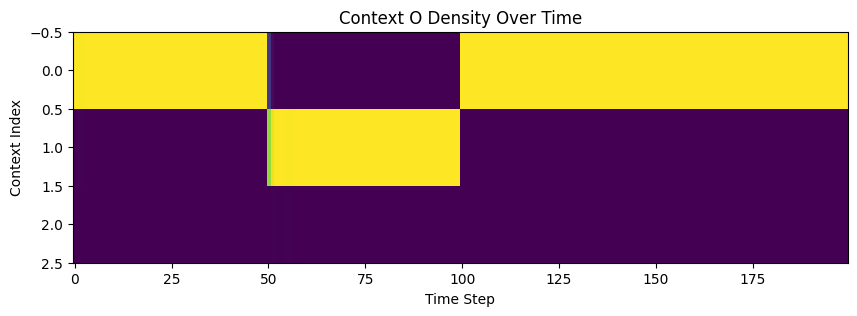

Context R History:


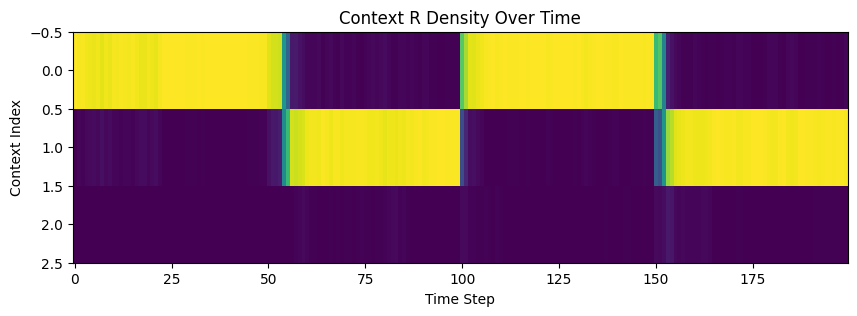

Actions History:


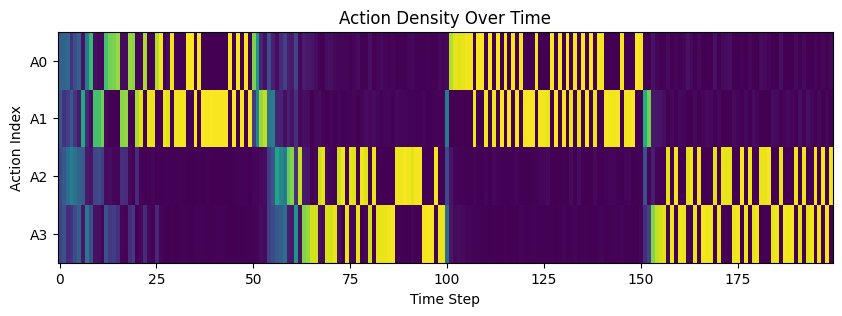

Proportion of Optimal Actions Over Time:


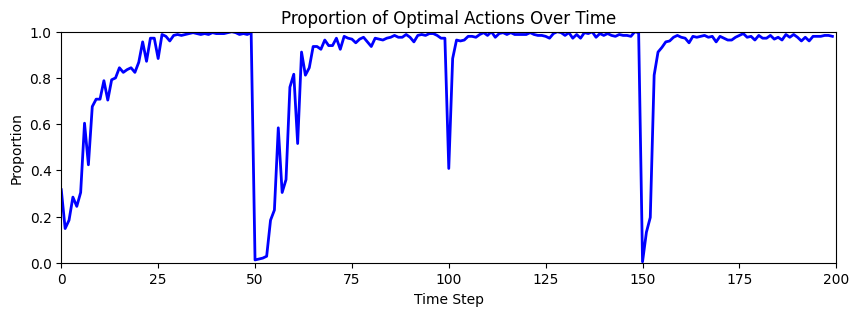

Jump History:


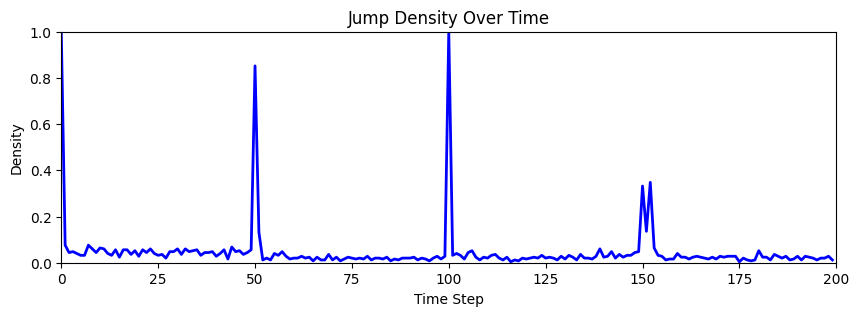

Inferred S History:


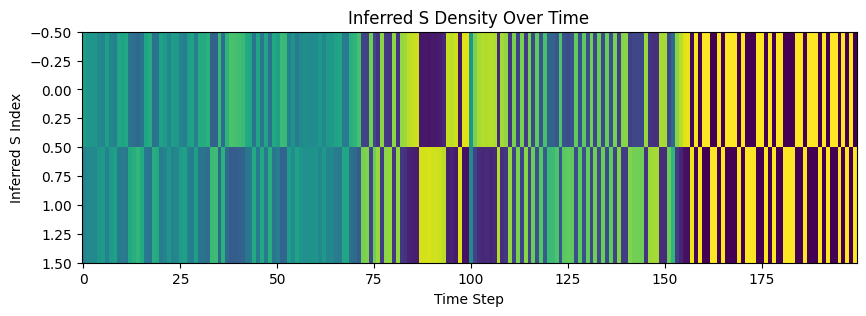

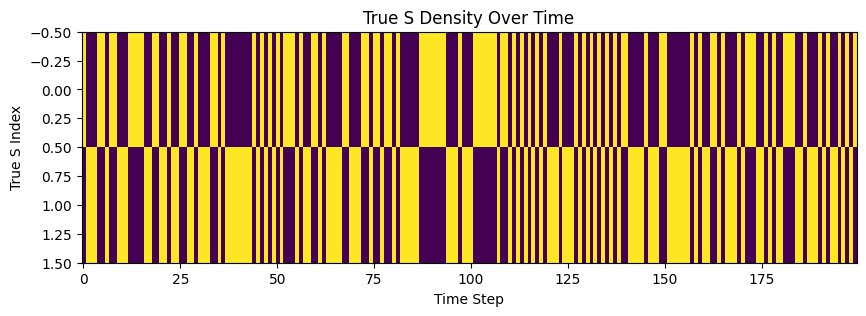

In [9]:
jump_times = []
j = 0
context_o_hist_arr = np.array(results[j]['context_o_hist'])
context_r_hist_arr = np.array(results[j]['context_r_hist'])
actions_hist_arr = np.array(results[j]['actions_hist'])
jumps_hist_arr = np.array(results[j]['jumps_hist'])
s_hist_arr = np.array(results[j]['inferred_s_hist'])

print("Context O History:")
max_context_o = np.max(context_o_hist_arr) + 1
context_o_densities = np.zeros((len(context_o_hist_arr), max_context_o))
for idx, element in enumerate(context_o_hist_arr):
    for val in element:
        context_o_densities[idx, val] += 1
context_o_densities = context_o_densities / context_o_densities.sum(axis=1, keepdims=True)

# set size of plot
plt.figure(figsize=(10, 3))
plt.imshow(context_o_densities.T, aspect='auto', cmap='viridis', interpolation='nearest')
#plt.colorbar(label='Density')
for jt in jump_times:
    plt.axvline(x=jt, color='red', linestyle='--', linewidth=2, alpha=0.7)


plt.xlabel('Time Step')
plt.ylabel('Context Index')
plt.title('Context O Density Over Time')
#plt.savefig("g_context_o_density.pdf")
plt.show()

print("Context R History:")
max_context_r = np.max(context_r_hist_arr) + 1
context_r_densities = np.zeros((len(context_r_hist_arr), max_context_r))
for idx, element in enumerate(context_r_hist_arr):
    for val in element:
        context_r_densities[idx, val] += 1
context_r_densities = context_r_densities / context_r_densities.sum(axis=1, keepdims=True)

plt.figure(figsize=(10, 3))
plt.imshow(context_r_densities.T, aspect='auto', cmap='viridis', interpolation='nearest')
#plt.colorbar(label='Density')
for jt in jump_times:
    plt.axvline(x=jt, color='red', linestyle='--', linewidth=2, alpha=0.7)
plt.xlabel('Time Step')
plt.ylabel('Context Index')
plt.title('Context R Density Over Time')
#plt.savefig("g_context_r_density.pdf")
plt.show()

print("Actions History:")
actions_densities = np.zeros((len(actions_hist_arr), 4))
for idx, element in enumerate(actions_hist_arr):
    #print(element)
    for val in element:
        actions_densities[idx, val] += 1
actions_densities = actions_densities / actions_densities.sum(axis=1, keepdims=True)

plt.figure(figsize=(10, 3))
plt.imshow(actions_densities.T, aspect='auto', cmap='viridis', interpolation='nearest')
#plt.colorbar(label='Density')
plt.yticks(ticks=[0, 1, 2, 3], labels=['A0', 'A1', 'A2', 'A3'])
for jt in jump_times:
    plt.axvline(x=jt, color='red', linestyle='--', linewidth=2, alpha=0.7)
plt.xlabel('Time Step')
plt.ylabel('Action Index')
plt.title('Action Density Over Time')
#plt.savefig("g_action_density.pdf")
plt.show()

print("Proportion of Optimal Actions Over Time:")
true_rewarding_actions = np.array(results[j]['true_rewarding_actions'])
proportion_optimal = np.zeros(len(actions_hist_arr))
for idx, element in enumerate(actions_hist_arr):
    proportion_optimal[idx] = np.sum(element == true_rewarding_actions[idx]) / len(element)
plt.figure(figsize=(10, 3))
plt.plot(proportion_optimal, label='Proportion Optimal Action', color='blue', linewidth=2)
plt.title('Proportion of Optimal Actions Over Time')
plt.xlabel('Time Step')
plt.ylabel('Proportion')
plt.ylim(0, 1)
plt.xlim(0, len(proportion_optimal))
for jt in jump_times:
    plt.axvline(x=jt, color='red', linestyle='--', linewidth=2, alpha=0.7)
#plt.savefig("g_proportion_optimal.pdf")
plt.show()

print("Jump History:")
jumps_densities = np.zeros(len(jumps_hist_arr))
for idx, element in enumerate(jumps_hist_arr):
    jumps_densities[idx] = np.sum(element) / ensemble.N

plt.figure(figsize=(10, 3))
plt.plot(jumps_densities, label='Jump', color='blue', linewidth=2)
plt.title('Jump Density Over Time')
plt.xlabel('Time Step')
plt.ylabel('Density')
plt.ylim(0, 1)
plt.xlim(0, len(jumps_densities))
for jt in jump_times:
    plt.axvline(x=jt, color='red', linestyle='--', linewidth=2, alpha=0.7)
#plt.savefig("g_jump_density.pdf")
plt.show()

print("Inferred S History:")
s_densities = np.zeros((len(s_hist_arr), 2))
for idx, element in enumerate(s_hist_arr):
    for val in element:
        s_densities[idx, val] += 1
s_densities = s_densities / s_densities.sum(axis=1, keepdims=True) 
plt.figure(figsize=(10, 3))
plt.imshow(s_densities.T, aspect='auto', cmap='viridis', interpolation='nearest')
#plt.colorbar(label='Density')
for jt in jump_times:
    plt.axvline(x=jt, color='red', linestyle='--', linewidth=2, alpha=0.7)
plt.xlabel('Time Step')
plt.ylabel('Inferred S Index')
plt.title('Inferred S Density Over Time')
#plt.savefig("g_inferred_s_density.pdf")
plt.show()

# plot true s history as an image
true_s_hist_arr = np.array(results[j]['true_s_hist'])
plt.figure(figsize=(10, 3))
true_s_densities = np.zeros((len(true_s_hist_arr), 2))
for idx, val in enumerate(true_s_hist_arr):
    true_s_densities[idx, val] += 1
true_s_densities = true_s_densities / true_s_densities.sum(axis=1, keepdims=True) 
plt.imshow(true_s_densities.T, aspect='auto', cmap='viridis', interpolation='nearest')
#plt.colorbar(label='Density')
for jt in jump_times:
    plt.axvline(x=jt, color='red', linestyle='--', linewidth=2, alpha=0.7)
plt.xlabel('Time Step')
plt.ylabel('True S Index')
plt.title('True S Density Over Time')
#plt.savefig("g_true_s_density.pdf")
plt.show()
